# Construye Patrones de Diseño LangGraph: Orquestación y Evaluación

En este laboratorio práctico, dominarás dos patrones de diseño de agentes fundamentales que impulsan los flujos de trabajo de IA modernos. Construirás un sistema paralelo de planificación de comidas que coordina a varios chefs de IA y un asesor de inversiones iterativo que perfecciona las recomendaciones mediante ciclos de retroalimentación continua.

**Impacto en el mundo real**: Estos patrones se utilizan en sistemas de producción de empresas líderes como Anthropic, OpenAI, Microsoft, IBM y Google, lo que permite a los agentes de IA colaborar, auto-mejorar y abordar tareas de razonamiento complejas de múltiples pasos en diversos ámbitos, desde la investigación hasta el servicio al cliente.

## ¿Por qué LangGraph?


A medida que los sistemas de IA abordan problemas más complejos, surge un desafío crucial: ¿Cómo podemos coordinar múltiples agentes o componentes para que trabajen de forma colaborativa, inteligente y adaptativa?

Aquí es donde entra en juego LangGraph.

LangGraph es un marco de trabajo para construir flujos de trabajo de IA modulares, dinámicos y con estado.

A diferencia de las cadenas lineales tradicionales, LangGraph permite:

- 🔄 **Refinamiento iterativo**: Incorpora bucles de retroalimentación y lógica de autocorrección.

- 🧵 **Enrutamiento condicional**: Elige dinámicamente diferentes rutas en función de los resultados intermedios.

- ⚡️ **Ejecución paralela**: Procesa subtareas independientes simultáneamente para aumentar la eficiencia.

- 🧠 **Gestión global del estado**: Mantiene y evoluciona un contexto compartido en flujos de trabajo complejos.

Con LangGraph, tus flujos de trabajo se convierten en algo más que simples tuberías; se transforman en sistemas inteligentes capaces de razonar, adaptarse y mejorar con el tiempo. Esto es **ideal** para casos de uso como la colaboración entre múltiples agentes, la toma de decisiones, los ciclos de evaluación y la planificación.

<img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/eXR9pjKDiPrPhLcEjhsKCA/langgraph.png" width="100%" alt="langgraph">


## __Table of Contents__

<ol>
    <li>
        <a href="#Orchestrator-Worker-Pattern">Orchestrator-Worker Pattern</a>
        <ol>
            <li><a href="#Structured-Output">Structured Output</a></li>
            <li><a href="#State-(Orchestration)">State (Orchestration)</a></li>
            <li><a href="#Orchestrator-Node">Orchestrator Node</a></li>
            <li><a href="#Worker-Nodes">Worker Nodes</a></li>
            <li><a href="#Building-the-Workflow-(Orchestration)">Building the Workflow (Orchestration)</a></li>
            <li><a href="#Visualization">Visualization</a></li>
            <li><a href="#Testing-(Orchestration)">Testing (Orchestration)</a></li>
        </ol>
    </li>
    <li>
        <a href="#Reflection-Pattern">Reflection Pattern</a>
        <ol>
            <li><a href="#State-(Reflection)">State (Reflection)</a></li>
            <li><a href="#Setup-Node">Setup Node</a></li>
            <li><a href="#Generator-Node">Generator Node</a></li>
            <li><a href="#Evaluator-Node">Evaluator Node</a></li>
            <li><a href="#Routing-Node">Routing Node</a></li>
            <li><a href="#Building-the-Workflow-(Reflection)">Building the Workflow (Reflection)</a></li>
            <li><a href="#Testing-(Reflection)">Testing (Reflection)</a></li>
        </ol>
    </li>
    <li>
        <a href="#Conclusion">Conclusion</a>
        <ol>
            <li><a href="#Next-Steps">Next Steps</a></li>
            <li><a href="#Authors">Authors</a></li>
        </ol>
    </li>
</ol>


## 1. Objetivos

Tras completar este laboratorio, podrá:

- Diseñar e implementar el patrón **Orquestador-Trabajador** para el procesamiento paralelo de tareas.

- Crear **bucles de reflexión** que permitan a los agentes mejorar iterativamente sus resultados.

- Gestionar estados complejos en **flujos de trabajo LangGraph de múltiples nodos**.

- Aplicar **enrutamiento condicional** para crear flujos de trabajo dinámicos e inteligentes.

- Depurar y visualizar flujos de ejecución de LangGraph.

- Identificar cuándo utilizar cada patrón en escenarios reales.

## 2. Configuración


### *2.1. Instalación de las Bibliotecas Necesarias*

Las siguientes bibliotecas necesarias no están preinstaladas en el su entorno. Debe ejecutar la siguiente celda para instalarlas. Este paso puede tardar varios minutos, tenga paciencia.

```bash
pip install -r requirements.txt
```

### *2.2. Importación de las Bibliotecas Necesarias*

Importa aquí todas las bibliotecas necesarias:

In [1]:
from langgraph.graph import StateGraph, END, START
from langgraph.types import Send

Importaciones para seguridad de tipo y gestión de estado:

In [2]:
import operator
from pprint import pprint
from pydantic import BaseModel, Field
from typing import TypedDict, Annotated, List, Literal

Importaciones para la visualización gráfica de nuestro flujo de trabajo:

In [3]:
from IPython.display import Image, display

Importaciones para la instanciación de la API de LangChain y LLM:

In [4]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

# Inicializar el modelo de lenguaje: usar gpt-4o-mini para una experimentación rentable.
llm = ChatOpenAI(model= "gpt-4o-mini", temperature= 0.7)

## 3. Patrón Orquestador-trabajador

El patrón orquestador-trabajador es un enfoque potente para gestionar tareas complejas e impredecibles, ya que las divide dinámicamente en partes manejables y las procesa en paralelo. Cuando no se puede predecir de antemano cuántas subtareas se necesitarán ni qué implicarán, este patrón destaca por analizar de forma inteligente la entrada, descomponerla en unidades de trabajo estructuradas y asignar trabajadores especializados para gestionar cada parte de forma independiente. Este patrón se utiliza ampliamente en sistemas de flujo de trabajo de IA reales, incluidas soluciones industriales como Watsonx Orchestrate de IBM (https://www.ibm.com/products/watsonx-orchestrate?utm_source=skills_network&utm_content=in_lab_content_link&utm_id=Lab-Agentic+Design+Patterns+in+LangGraph-v1_1752612018).

Imagínelo como una cocina de catering muy concurrida que recibe pedidos para grandes eventos: cuando un cliente pide "Quiero una comida de tres platos, hamburguesas para el almuerzo y pizza para la cena", el chef principal (organizador) analiza la solicitud y la desglosa en platos específicos, luego asigna consultores culinarios especializados para crear planes de comidas detallados para cada tipo de cocina. Cada consultor se especializa en una cocina específica; por ejemplo, un experto en cocina italiana se encarga de la planificación de la pizza, mientras que un especialista en cocina estadounidense desarrolla el menú de hamburguesas. La clave es que cada consultor recibe un **informe claro y estructurado** con los requisitos de los platos y las consideraciones dietéticas, no solo "planifique algo bueno". En nuestro sistema de planificación de comidas, las solicitudes de los usuarios, como "alimentar a mi familia para la semana", pueden resultar en entre 3 y 15 platos diferentes, cada uno de los cuales requiere la experiencia de un consultor especializado en su cocina particular para crear planes de comidas completos.

<img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/XKXeMzLe9KNW5UjYiJpuSQ/orchestration.png" width="100%" alt="orchestration">

### *3.1. Salida Estructurada*

El orquestador **debe** generar **salidas estructuradas** porque nuestros nodos de trabajo requieren formatos de entrada y salida específicos y bien definidos para procesar la información de forma fiable. Cada trabajador (chef consultor) se especializa en recopilar información específica sobre la cocina que se le ha asignado:

- Nombre del plato (por ejemplo, «Pizza Margarita», «Hamburguesa Clásica con Queso»)
- Lista de ingredientes (la parte más importante para la planificación de menús)
- Tipo de cocina u origen cultural del plato (por ejemplo, italiana, americana, mexicana)

Para cada trabajador, agregamos estos datos en un formato estructurado llamado «Plato». A continuación, podemos almacenar una lista de platos con la clase «Platos».

In [61]:
# Esquema del plato para un solo plato.
class Plato(BaseModel):
    nombre: str = Field(
        description= "Nombre del plato (por ejemplo, espaguetis a la boloñesa, pollo al curry)."
    )
    ingredientes: List[str] = Field(
        description= "Lista de ingredientes necesarios para este plato, separados por comas."
    )
    localizacion: str = Field(
        description= "Origen cultural del plato (por ejemplo, italiana, india, mexicana)."
    )

# Esquema de platos para una lista de objetos Plato.
class Platos(BaseModel):
    platos: List[Plato] = Field(
        description= "Una lista de secciones de la compra, una para cada plato, con sus ingredientes."
    )

La siguiente instrucción transforma la solicitud de comida del usuario en fichas de recetas estructuradas que los cocineros especializados pueden procesar de forma fiable, tal como se describe en nuestro ejemplo del coordinador de cocina de catering, donde el chef principal desglosa los pedidos complejos en tareas claras y concretas para los cocineros especializados.

**Nota**: Opcionalmente, puede incluir los nombres de los campos del esquema (nombre, ingredientes, ubicación) en la instrucción para mayor claridad, pero no es necesario al usar la salida estructurada.

In [62]:
# Construir el prompt.
prompt_plato = ChatPromptTemplate.from_messages([
    (
        "system",
        "Eres un asistente que genera una lista de compras estructurada.\n\n"
        "El usuario desea preparar las siguientes comidas: {comidas}\n\n"
        "Para cada comida, devuelve una sección con:\n"
        "- el nombre del plato\n"
        "- una lista de ingredientes separados por comas necesarios para ese plato.\n"
        "- la cocina o el origen cultural de la comida"
    )
])

Para el planificador, encadenamos la solicitud al LLM y usamos `with_structured_output()` para formatear la salida con la clase `Dishes`:

In [63]:
# Utilice LCEL para canalizar el mensaje a un LLM con una salida estructurada de Platos.
cadena_planificadora = prompt_plato | llm.with_structured_output(Platos)

# Invoca el cadena_planificadora con ejemplos de comidas.
cadena_planificadora.invoke({ "comidas" : ["banana smoothie", "carrot cake"]})

Platos(platos=[Plato(nombre='banana smoothie', ingredientes=['bananas', 'leche', 'miel', 'hielo', 'vainilla'], localizacion='americana'), Plato(nombre='carrot cake', ingredientes=['zanahorias', 'harina', 'azúcar', 'huevos', 'aceite', 'canela', 'nueces', 'crema de queso'], localizacion='británica')])

Esto crea una canalización de procesamiento donde la solicitud guía el razonamiento del LLM, y `with_structured_output(Dishes)` garantiza que la respuesta se ajuste automáticamente a nuestra estructura de esquema Pydantic definida.

### *3.2. Estado (Orquestación)*

En LangGraph, el **estado** es la memoria compartida que fluye a través del flujo de trabajo. Captura todo lo que los agentes o nodos necesitan saber, modificar o transmitir al siguiente paso.

Imagínelo como la **mochila de contexto** que se transporta de nodo a nodo.

A diferencia de una cadena tradicional donde solo se transmiten la entrada y la salida, LangGraph proporciona a cada nodo acceso a un diccionario de estado estructurado, que puede contener:

- La entrada o el objetivo original del usuario.

- Resultados intermedios (por ejemplo, secciones analizadas, planes completados).

- Resúmenes o evaluaciones finales.

- Datos para la toma de decisiones o el enrutamiento (por ejemplo, nivel de riesgo, número de reintentos).

#### 3.2.1. Por qué el estado importa en los flujos de trabajo con agentes

Los sistemas basados ​​en agentes suelen implicar múltiples pasos, roles y puntos de decisión. Un estado compartido y evolutivo permite a los agentes:

- Acceder al contexto relevante de pasos anteriores.

- Modificar o enriquecer el estado durante su ejecución.

- Enrutar la lógica dinámicamente según las condiciones.

- Repetir, reintentar o reflexionar en función del estado.

In [64]:
class Estado(TypedDict):
    comidas: str  # La entrada del usuario enumera las comidas a preparar
    platos: List[Plato] # Una sección por comida/plato con los ingredientes.
    menu_completado: Annotated[List[str], operator.add]  # Guía de platos escrita por el trabajador.
    guia_final_comida: str  # Menú completo y legible.

- `comidas` es la entrada inicial del usuario.

- `platos` será la lista estructurada de cada plato creada por el orquestador.

- `menu_completado` será la salida de cada trabajador (especialista en comidas), con `operator.add` agregando automáticamente los resultados de todos los trabajadores en paralelo.

- `guia_final_comida` será la agregación final de todas las salidas de los trabajadores en una guía completa de planificación de comidas.

Probemos el planificador LLM antes de crear un nodo LangGraph. Inicializamos un estado ficticio con todos los campos en blanco excepto la clave `comidas`, y luego invocamos el planificador para ver cómo estructura la entrada del usuario en secciones de platos organizadas.

In [65]:
# Crear un estado ficticio para probar nuestros nodos de trabajo.
estado_ejemplo: Estado = {
    "comidas": "Spaghetti Bolognese and Chicken Stir Fry",
    "platos": [],
    "menu_completado": [],
    "guia_final_comida": ""
}

reporte_platos = cadena_planificadora.invoke({"comidas": estado_ejemplo['comidas']})

Podemos imprimir la salida del LLM para ver su estructura. El resultado es un objeto `Platos` que contiene un atributo `platos`, que es esencialmente una lista de objetos `Platos` con los atributos `nombre`, `ingredientes` y `localizacion` completados para cada plato (comida italiana y china, respectivamente). Podemos iterar sobre ellos e imprimirlos:

In [66]:
for i, section in enumerate(reporte_platos.platos):
    print(f"Plato {i+1}\n")
    # add each dish to our dummy state
    estado_ejemplo["platos"].append(section)

    print(f"Nombre del Item: {section.nombre}")
    print(f"Ubicación/Cocina: {section.localizacion}")
    print(f"Ingredientes: {", ".join(section.ingredientes)}.")

Plato 1

Nombre del Item: Spaghetti Bolognese
Ubicación/Cocina: italiana
Ingredientes: spaghetti, carne molida de res, cebolla, ajo, zanahoria, apio, tomate triturado, vino tinto, aceite de oliva, sal, pimienta, queso parmesano.
Plato 2

Nombre del Item: Chicken Stir Fry
Ubicación/Cocina: china
Ingredientes: pechuga de pollo, pimientos, brócoli, zanahoria, cebolla, salsa de soja, aceite de sésamo, jengibre, ajo, arroz.


### *3.3. Nodo Orquestador*

El **orquestador** se encarga de la planificación de alto nivel y actúa como coordinador central en el flujo de trabajo de LangGraph. Recibe la entrada del usuario y genera subtareas estructuradas para que otros nodos las procesen.

En nuestro flujo de trabajo, el orquestador:

- Recibe la entrada sin procesar (por ejemplo, «Espaguetis a la boloñesa y pollo salteado»).

- Utiliza un modelo de lenguaje de programación (LLM) para descomponerla en objetos estructurados de tipo «Plato».

- Devuelve el resultado como un diccionario con el campo «secciones» para que los nodos de trabajo lo procesen.

Esto permite el **paralelismo distribuido**, donde varios nodos de trabajo pueden actuar de forma independiente.

In [67]:
def nodo_orquestador(estado: Estado):
    """Orquestador que genera una lista de platos estructurada a partir de las comidas proporcionadas."""

    # Utilice el LLM cadena_planificadora para dividir la lista de comidas del usuario en secciones de platos estructuradas.
    descripcion_platos = cadena_planificadora.invoke({"comidas": estado["comidas"]})

    # Devuelve la lista de secciones de platos que se pasarán a los nodos de trabajo.
    return {"platos": descripcion_platos.platos}

### *3.4. Nodos de Trabajo*

Cada **nodo de trabajo** procesa una única unidad de trabajo, normalmente un elemento de `ESTADO["platos"]`.

En este caso, cada trabajador será un chef. El mensaje del sistema de la plantilla de solicitud especifica la entrada utilizando las salidas del esquema del orquestador. Por ejemplo, un trabajador hará lo siguiente:

- Leerá un objeto `Plato` (por ejemplo, "Espaguetis a la boloñesa").

- Utilizará un LLM para generar una receta o instrucciones detalladas.

- Añadirá el resultado a `estado["menu_completado"]`.

Los trabajadores están diseñados para estar **aislados**, de modo que solo ven una parte del estado y devuelven una salida.

Primero crearemos la solicitud para obtener una guía para cada plato de un chef profesional:

In [68]:
prompt_chef = ChatPromptTemplate.from_messages([
    (
        "system",
        "Eres un chef de talla mundial de {localizacion}.\n\n"
        "Preséntate brevemente y describe detalladamente la preparación del plato: {nombre}.\n"
        "Tu respuesta debe incluir:\n"
        "- Un saludo, tu nombre y tu experiencia culinaria.\n"
        "- Una lista clara de los pasos de preparación.\n"
        "- Una explicación completa del proceso de cocción.\n\n"
        "Utiliza los siguientes ingredientes: {ingredientes}"
    )
])

Luego encadenamos la solicitud al LLM, creando un `chef_llm`:

In [97]:
cadena_chef = prompt_chef | llm

El `EstadoTrabajador` define la forma del estado que cada **nodo trabajador individual de Chef** recibe y devuelve.

In [98]:
class EstadoTrabajador(TypedDict):
    plato: Plato
    menu_completado: Annotated[list, operator.add] # Lista con operadores de suma entre elementos.

La función `asignar_trabajadores` extrae cada objeto `Plato` de la clave `platos` y lo pasa al nodo de trabajador `trabajador_chef`, que aún no hemos definido. Para ello, primero extrae cada sección `p` del alor `platos` en la variable de estado. Luego, la función `Send()` pasa `p` al nodo `trabajador_chef` a través de la clave `plato`.

In [99]:
def asignar_trabajadores(estado: Estado):
    """Asignar una trabajadora a cada sección del plan"""
    
    # Inicie la redacción de la sección en paralelo mediante la API Send().
    return [Send("trabajador_chef", {"plato": p}) for p in estado["platos"]]

A continuación, encapsulamos el `cadena_chef` como un nodo de trabajo llamado `trabajador_chef`. Cada trabajador se encarga de tomar una sección de plato, proporcionada a través del nodo `asignar_trabajadores` mediante `EstadoTrabajador`, y generar un plan de cocina detallado para esa comida.

Las entradas se pasan a través del estado del trabajador mediante la variable `plato`, que es de tipo `Plato`. El nodo `asignar_trabajadores` extrae esta información del nodo orquestador y la pasa al LLM.

Las salidas se guardan en `menu_completado`. Dado que el estado y el trabajador comparten este valor, el estado principal se actualiza automáticamente.

In [100]:
def trabajador_chef(estado: EstadoTrabajador):
    """Nodo de trabajo que genera las instrucciones de cocina para una sección de una comida."""

    # Utiliza el modelo de lenguaje para generar un plan de preparación de comidas.
    # El modelo recibe el nombre del plato, la ubicación y los ingredientes de la sección actual.
    meal_plan = cadena_chef.invoke({
        "nombre": estado["plato"].nombre,
        "localizacion": estado["plato"].localizacion,
        "ingredientes": estado["plato"].ingredientes
    })

    # Devuelve el plan de comidas generado envuelto en una lista bajo completed_sections.
    # Esto se fusionará con el estado principal usando operator.add en LangGraph.
    return {"menu_completado": [meal_plan.content]}


Podemos replicar lo que sucede con un bucle 'for', iterando a través de las secciones de estado del trabajador ficticio y pasando cada sección al LLM del chef, para luego agregar los resultados a `menu_completado`:

In [103]:
ejemplos_platos: List[Plato] = estado_ejemplo["platos"]

# Simular el comportamiento de ramificación y fusión de LangGraph.
for plato in ejemplos_platos:
    # Construir un estado trabajador individual.
    estado_trabajador: EstadoTrabajador = {
        "plato": plato,
        "menu_completado": []  # LangGraph fusiona esto más adelante.
    }

    # Llamar directamente a la lógica del trabajador.
    resultado = trabajador_chef(estado_trabajador)
    print(resultado)

    # Fusionar el resultado en un menú combinado (LangGraph haría esto con operator.add).
    estado_ejemplo["menu_completado"] += resultado["menu_completado"]

{'menu_completado': ['¡Buongiorno! Soy Chef Marco Rossi, un apasionado de la cocina italiana con más de 20 años de experiencia en restaurantes de renombre en Italia y en el extranjero. Me encanta compartir la rica tradición culinaria de mi país, y hoy quiero enseñarte a preparar un clásico delicioso: Spaghetti Bolognese.\n\n### Ingredientes\n\n- 400 g de spaghetti\n- 500 g de carne molida de res\n- 1 cebolla mediana, picada finamente\n- 2 dientes de ajo, picados\n- 1 zanahoria, pelada y picada en cubitos\n- 1 tallo de apio, picado en cubitos\n- 400 g de tomate triturado\n- 150 ml de vino tinto\n- 2 cucharadas de aceite de oliva\n- Sal al gusto\n- Pimienta al gusto\n- Queso parmesano rallado para servir\n\n### Pasos de Preparación\n\n1. **Preparar los ingredientes**: Pica finamente la cebolla, el ajo, la zanahoria y el apio. Ten todo listo para que la cocción sea más fluida.\n   \n2. **Cocinar la carne**: En una sartén grande, calienta el aceite de oliva a fuego medio-alto. Agrega la ca

Para obtener el resultado final, simplemente concatenamos los elementos de `menu_completado` e imprimimos los primeros 1000 caracteres:

In [104]:
platos_menu_completados = "\n".join(estado_ejemplo["menu_completado"])
print(platos_menu_completados[:1000])

¡Buongiorno! Mi nombre es Giovanni Rossi, y tengo el placer de ser un chef especializado en la cocina italiana con más de 20 años de experiencia en restaurantes de renombre en Italia y el resto del mundo. Hoy, les voy a guiar en la preparación de un clásico que ha conquistado paladares: ¡Spaghetti Bolognese!

### Ingredientes:

- 400 g de spaghetti
- 500 g de carne molida de res
- 1 cebolla grande
- 2 dientes de ajo
- 1 zanahoria
- 1 tallo de apio
- 400 g de tomate triturado
- 150 ml de vino tinto
- 2 cucharadas de aceite de oliva
- Sal al gusto
- Pimienta al gusto
- Queso parmesano rallado para servir

### Pasos de preparación:

1. **Preparar los ingredientes**: Pica finamente la cebolla, el ajo, la zanahoria y el apio.
2. **Calentar el aceite**: En una sartén grande, calienta el aceite de oliva a fuego medio.
3. **Sofreír las verduras**: Agrega la cebolla, el ajo, la zanahoria y el apio a la sartén. Sofríe durante unos 5-7 minutos, hasta que las verduras estén tiernas y la cebolla es

Podemos convertir el proceso anterior en un nodo **sintetizador** en LangGraph. El nodo sintetizador toma las respuestas de todos los nodos de trabajo y las agrega para generar un flujo de trabajo final.

El resultado se almacenará en la clave `guia_final_comida`.

In [106]:
def sintetizador(estado: Estado):
    """Sintetizar el informe completo a partir de las secciones"""

    # Lista de platos completados.
    platos_completados = estado["menu_completado"]

    # Formatear la sección completada a una cadena de texto para usarla como contexto para las secciones finales.
    guia_final = "\n\n---\n\n".join(platos_completados)

    return {"guia_final_comida": guia_final}

### *3.5. Creación del Flujo de Trabajo (Orquestación)*

Para construir un flujo de trabajo con agentes en LangGraph, utilizamos un `StateGraph`, una estructura gráfica flexible que coordina cómo los nodos procesan y actualizan el estado compartido.

Cada nodo del grafo representa un **paso de computación modular**, como la planificación, la generación, la evaluación o la síntesis. El `StateGraph` define cómo se conectan estos nodos y cómo fluyen los datos (estado) entre ellos. En un `StateGraph`, el estado de entrada se desplaza a través del flujo de trabajo, actualizándose en cada etapa; por ello, la convención de nomenclatura del estado se mantiene constante a lo largo del flujo de trabajo.

#### 3.5.1. Pasos

1. **Inicializa el grafo** con un esquema de `Estado` que define qué información persistirá y evolucionará a lo largo del flujo de trabajo.

2. **Añade nodos** usando `.add_node(nombre, función)`, donde cada nodo opera sobre una parte del estado.
- `orquestador`, `trabajador_chef` y `sintetizador`
4. **Conecta los nodos** usando:

- `.add_edge(from_node, to_node)` para pasos secuenciales simples.

- `.add_conditional_edges(...)` para enrutamiento dinámico o ramificación paralela.

5. **Compila el grafo** para finalizar la estructura y la validación.

In [110]:
# Instanciar el constructor.
constructor_orquestador_trabajador = StateGraph(Estado)

# Agregar los nodos.
constructor_orquestador_trabajador.add_node("orquestador", nodo_orquestador)
constructor_orquestador_trabajador.add_node("trabajador_chef", trabajador_chef)
constructor_orquestador_trabajador.add_node("sintetizador", sintetizador)

A continuación, añadimos una arista condicional desde el nodo `orquestador` hasta `trabajador_chef`, lo que creará un número variable de nodos a partir de la función `asignar_trabajadores`. `orquestador` es el nodo de origen, `asignar_trabajadores` es la función de enrutamiento especial que hemos creado y `trabajador_chef` es el nodo de destino del trabajador:

In [111]:
constructor_orquestador_trabajador.add_conditional_edges(
    "orquestador", asignar_trabajadores, ["trabajador_chef"] # nodo de origen, función de enrutamiento, lista de objetivos permitidos.
)

Finalmente, definimos el punto de entrada conectando `START` al nodo orquestador, que **iniciará** el proceso de planificación de comidas cuando se invoque el flujo de trabajo. También conectamos todas las salidas de los trabajadores al nodo sintetizador y luego conectamos el sintetizador al nodo `END` para **completar** el flujo de trabajo:

In [112]:
# Agregar las aristas, conexiones entre nodos.
constructor_orquestador_trabajador.add_edge(START, "orquestador")
constructor_orquestador_trabajador.add_edge("trabajador_chef", "sintetizador")
constructor_orquestador_trabajador.add_edge("sintetizador", END)

Compilamos el generador de flujos de trabajo en un gráfico ejecutable que puede procesar nuestras solicitudes de planificación de comidas:

In [113]:
# Compila el generador para obtener un ejecutable de flujo de trabajo completo.
orquestador_trabajador = constructor_orquestador_trabajador.compile()

### *3.6. Visualización*

LangGraph ofrece soporte integrado para visualizar flujos de trabajo mediante [**Mermaid**](https://docs.mermaidchart.com/mermaid/intro), una sintaxis de diagramación ligera.

El diagrama Mermaid te ayuda a:

- Ver cómo se conectan los nodos (por ejemplo, `orquestador`, `trabajador_chef`, `sintetizador`).

- Identificar bucles, ramificaciones o flujos condicionales.

- Comprender cómo se mueve el estado a través del flujo de trabajo.

Esto es especialmente útil para depurar, comunicar la lógica del flujo de trabajo o validar la estructura de sistemas complejos basados ​​en agentes antes de su ejecución.

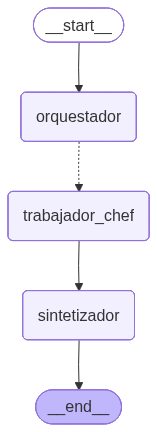

In [114]:
# Visualice el flujo de trabajo del orquestador utilizando el gráfico Mermaid.
display(Image(orquestador_trabajador.get_graph().draw_mermaid_png()))

### *3.7. Testing (Orquestación)*


Finalmente, probaremos el flujo de trabajo invocándolo con una solicitud de comida de ejemplo para ver el proceso de planificación de comidas de principio a fin en acción:

In [115]:
# Invocar el flujo de trabajo con una cadena de comidas en un diccionario.
respuesta = orquestador_trabajador.invoke({"comidas": "Lomo saltado, tacos, and bandeja paisa"})

In [116]:
# Imprime los primeros 2000 caracteres de nuestra guía_final_comida.
pprint(respuesta["guia_final_comida"][:2000])

('¡Hola! Soy Chef Alejandro, un apasionado de la cocina peruana con más de 15 '
 'años de experiencia en la gastronomía. He tenido el privilegio de trabajar '
 'en reconocidos restaurantes tanto en Perú como en el extranjero, y hoy '
 'quiero compartir contigo la receta de uno de los platos más emblemáticos de '
 'nuestra cultura: el Lomo Saltado.\n'
 '\n'
 '### Ingredientes:\n'
 '- 500 g de lomo de res, cortado en tiras\n'
 '- 1 cebolla roja, cortada en plumas\n'
 '- 2 tomates, cortados en gajos\n'
 '- 2 tazas de papas fritas\n'
 '- Un puñado de culantro (cilantro) fresco, picado\n'
 '- 3 cucharadas de salsa de soja\n'
 '- 1 cucharada de vinagre\n'
 '- 2 dientes de ajo, picados finamente\n'
 '- Sal al gusto\n'
 '- Pimienta al gusto\n'
 '- Aceite vegetal para freír\n'
 '\n'
 '### Pasos de preparación:\n'
 '\n'
 '1. **Preparar los ingredientes**: Corta el lomo de res en tiras de '
 'aproximadamente 1.5 cm de ancho. Lava y corta la cebolla roja en plumas, los '
 'tomates en gajos y pica 

## 4. Patrón de reflexión

El patrón de reflexión consiste en que un agente de IA evalúa y mejora iterativamente sus propios resultados mediante autoevaluación y ciclos de retroalimentación, de forma similar a los agentes reflexivos en la ciencia cognitiva. En lugar de ofrecer una única recomendación, el sistema crea una propuesta inicial, la evalúa críticamente según criterios establecidos y, a continuación, refina el resultado en función de dicha evaluación. Este ciclo continúa hasta que el sistema alcanza una solución óptima que cumple con los estándares de calidad predefinidos.

En esta sección, construiremos un sistema inteligente de asesoramiento de inversiones que refina iterativamente las recomendaciones de cartera mediante evaluación continua y ciclos de retroalimentación. El sistema combina estrategias de crecimiento agresivas con una evaluación de riesgos conservadora para encontrar el equilibrio óptimo para el perfil de cada inversor. El patrón de reflexión permite al sistema autocorregirse y adaptar sus recomendaciones, garantizando que cada sugerencia de cartera se haya revisado exhaustivamente antes de presentarla al inversor.

<img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/9kH761sRFhuVPWzBUZhgkA/reflection.png" width="100%" alt="reflection">

### *4.1. Estado (Reflexion)*

De forma similar al flujo de trabajo anterior, también utilizaremos un estado para realizar un seguimiento de las variables y los valores a lo largo de este flujo de trabajo. El siguiente diccionario `State` representa el contexto en evolución en un **flujo de trabajo de Evaluador-Optimizador de Asesoramiento de Inversión**, que realiza un seguimiento del perfil de inversión del usuario, su plan de inversión, la retroalimentación del evaluador, el perfil de seguridad (o riesgo) del usuario, el perfil de seguridad objetivo y un contador `n` para las iteraciones.

In [123]:
grados = Literal[
    "ultra-conservador", 
    "conservador", 
    "moderado", 
    "agresivo", 
    "alto riesgo"
]

class Estado(TypedDict):
    plan_inversion: str
    perfil_inversionista: str
    perfil_seguridad: grados
    comentarios: str
    grado: grados
    n: int = 0

- `plan_inversion`: Nuestro plan generado que será evaluado y revisado si es necesario

- `perfil_inversionista`: el perfil ingresado por el usuario que usaremos como referencia para el plan.

- `perfil_seguridad`: un grado de tolerancia al riesgo ideal generado en función del perfil del inversor.

- `comentarios`: Comentarios del evaluador sobre el plan de inversión.

- `grado`: Grado evaluado del plan de inversión

- `n`: Número de iteraciones de evaluación

**Nota:** Ambos campos de calificación son "literales", lo que significa que solo pueden tomar un valor dentro de la lista definida.

### *4.2. Nodo de Configuración*

Antes de construir nuestros nodos Generador y Evaluador, creemos un nodo que determine un "perfil_seguridad" adecuado según el perfil del inversor. Este valor permanecerá **estático** durante todo el flujo de trabajo de evaluación y existe para impulsar el resultado generado hacia una dirección general.

Comenzaremos creando el mensaje y la canalización para obtener `perfil_seguridad`:

In [169]:
prompt_perfil_seguridad = ChatPromptTemplate.from_messages([
    ("system",
     "Usted es un asesor de inversiones. Dado el perfil del inversor y su plan propuesto." 
    "Elija exactamente una clasificación de riesgo entre: ultraconservadora, conservadora, moderada, agresiva y de alto riesgo."
    "Devuelva SÓLO la calificación."
    ),
    ("user",
     "Perfil del inversor:\n\n{perfil_inversionista}\n\n"
    )
])

cadena_perfil_seguridad = prompt_perfil_seguridad | llm

Usando la tubería podemos crear una función (nodo) para devolver el dict con la clave `target_grade` ideal:

In [176]:
def determinar_grado_objetivo(estado: Estado) -> Estado:
    """Pídale a la LLM que elija el target_grade que mejor se ajuste."""
    response = cadena_perfil_seguridad.invoke({
        "perfil_inversionista": estado["perfil_inversionista"]
    })
    
    # Regresar como un dictado simple para que LangGraph pueda fusionarlo en el estado.
    return {"perfil_seguridad": response.content.lower()}

De manera similar al **flujo de trabajo de orquestación**, usaremos un `estado_ejemplo` para probar nuestros nodos. Inicialicémoslo con un perfil de inversor de ejemplo:

In [188]:
# Inicializar el estado vacío excepto el perfil de inversor ingresado por el usuario.
estado_ejemplo: Estado = {
    "plan_inversion": "",
    "perfil_inversionista": (
        "Edad: 29\n"
        "Salario: $110,000\n"
        "Activos: $40,000\n"
        "Objetivo: Lograr la independencia financiera antes de los 45 años\n"
        "Tolerancia al riesgo: Alta\n"
    ),
    "perfil_seguridad": "",
    "comentarios": "",
    "grado": "",
    "n": 0
}

Usando la función podemos determinar una calificación objetivo y actualizar el estado ficticio:

In [189]:
# Obtener la calificación objetivo.
perfil_seguridad = determinar_grado_objetivo(estado_ejemplo)

estado_ejemplo.update(perfil_seguridad)

pprint(estado_ejemplo)

{'comentarios': '',
 'grado': '',
 'n': 0,
 'perfil_inversionista': 'Edad: 29\n'
                         'Salario: $110,000\n'
                         'Activos: $40,000\n'
                         'Objetivo: Lograr la independencia financiera antes '
                         'de los 45 años\n'
                         'Tolerancia al riesgo: Alta\n',
 'perfil_seguridad': 'agresiva',
 'plan_inversion': ''}


### *4.3. Nodo Generador*

El primer paso en el flujo de trabajo de Reflection es el **nodo generador**, que produce un plan de inversión basado en el perfil de un inversor. El nodo generador es el responsable de elaborar una estrategia de inversión basada en el perfil del inversor. Sin embargo, en lugar de generar un plan único, diseñamos un **generador de múltiples fases** que evoluciona a través de la retroalimentación: comenzando con negrita y luego refinando según la evaluación.

#### 4.3.1. Fase 1: Generación inicial

En esta estrategia inicial generada, simulamos el estilo de **Cathie Wood**, una conocida inversora que adopta un enfoque de estilo de riesgo: favoreciendo oportunidades de alto crecimiento y alto riesgo sobre estrategias conservadoras basadas en valor.

Para modelar esto, definimos:

- Un **mensaje del sistema** que describe la filosofía de inversión de Cathie Wood: audaz, centrada en la tecnología y especulativa.

- Un **mensaje de usuario** que proporciona el perfil concreto del inversor.

- Un **LLM encadenado**, `cadena_cathie_wood`, que combina ambos mensajes en un canal de generación estructurado.

Este nodo generador sirve como **iniciador creativo** del flujo de trabajo, produciendo una estrategia de inversión candidata que los nodos posteriores evaluarán, criticarán o perfeccionarán posteriormente:

In [152]:
# inital generation, no feedback, only based on profile
prompt_cathie_wood = ChatPromptTemplate.from_messages([
    ("system",
    """
    Eres un asesor de inversiones audaz e impulsado por la innovación inspirado en Cathie Wood.

    Su objetivo es generar un plan de inversión con visión de futuro y de alta convicción que abarque tecnologías disruptivas,
    mercados emergentes y potencial de crecimiento a largo plazo. No le teme a la volatilidad a corto plazo siempre que el lado positivo sea transformador.

    Cree una estrategia de inversión adaptada al perfil de inversor que aparece a continuación. Priorizar la innovación y las oportunidades de alta recompensa,
    como la inteligencia artificial, la biotecnología, el blockchain o las energías renovables.

    Responda con un plan de inversión conciso en forma de párrafo.
    """
    ),
    ("human", "Perfil de inversor:\n\n{perfil_inversionista}\n\n")
])

cadena_cathie_wood = prompt_cathie_wood | llm

La segunda fase del generador requerirá retroalimentación del evaluador, así que formateemos la salida del evaluador para la generación posterior. Una vez generado el plan inicial, un agente evaluador lo analizará y devolverá un esquema estructurado de "Retroalimentación":

In [153]:
# Esquema de salida del evaluador.
class Feedback(BaseModel):
    grado: grados = Field(
        description= "Clasifique la inversión según el nivel de riesgo, desde ultraconservadora hasta alto riesgo."
    )
    comentarios: str = Field(
        description= "Fundamentar la clasificación de riesgo asignada a la sugerencia de inversión."
    )

#### 4.3.2. Fase 2: Generación Adaptativa

Para mejorar el plan inicial, presentamos un segundo generador, esta vez inspirado por **Ray Dalio**, un inversor más conservador y con bases macroeconómicas. Esta parte toma la "Retroalimentación" ("calificación" y "retroalimentación") del **evaluador** junto con el "perfil_inversor" del estado. Esto se hace a través del **mensaje humano** mientras el LLM imagina una conversación en la que recibió comentarios previos.

Para modelar esto, definimos:
- Un **mensaje del sistema** que describe la estrategia de inversión de Ray Dalio: conservadora.

- Un **mensaje humano** que proporciona el perfil específico del inversor y el feedback.

- Un **LLM encadenado**, `cadena_ray_dalio`, que combina ambos mensajes en un canal de generación estructurado.

In [154]:
prompt_ray_dalio = ChatPromptTemplate.from_messages([
    ("system",
    """Eres un asesor de inversiones inspirado en los principios de Ray Dalio pero con generación de estrategias adaptativas.
    Su objetivo es crear planes de inversión variados y conscientes de los escenarios que respondan dinámicamente a las condiciones económicas.
    retroalimentación y las necesidades cambiantes del inversionista. Adaptas tus recomendaciones en base a evaluaciones anteriores.

    PRINCIPIOS BÁSICOS:
    - Diversificación ambiental entre regímenes económicos (combinaciones de crecimiento/inflación)
    - Ponderación de paridad de riesgo por volatilidad, no solo por montos en dólares
    - Selección de activos consciente de la inflación con enfoque en el rendimiento real
    - Planificación de escenarios macroeconómicos e identificación de regímenes.

    REGLAS DE ADAPTACIÓN basadas en feedback:
    - Si se considera "demasiado conservador" → Aumentar la asignación de capital de crecimiento, agregar mercados emergentes, considerar alternativas
    - Si se considera "demasiado agresivo" → Agregar activos defensivos, aumentar la asignación de bonos, centrarse en acciones con dividendos
    - Si "carece de protección contra la inflación" → Enfatice TIPS, materias primas, REIT, exposición internacional
    - Si es "demasiado complejo" → Simplificar a la estrategia central del ETF con una justificación clara.
    - Si hay "diversificación insuficiente" → Agregar exposición geográfica, sectorial o de activos alternativos

    AJUSTES DEL ESCENARIO ECONÓMICO:
    - Entorno de inflación creciente → Enfatizar las materias primas, TIPS, bienes raíces, reducir la duración
    - Preocupaciones por la estanflación → Centrarse en energía, materiales, mercados internacionales, coberturas contra la inflación.
    - Riesgos deflacionarios → Aumentar los bonos gubernamentales, los bonos corporativos de alta calidad y las posiciones de efectivo.
    - Aceleración del crecimiento → Favorecer la tecnología, el consumo discrecional y el crecimiento de las empresas de pequeña capitalización.
    - Incertidumbre económica → Equilibrio con un enfoque "para todo clima" utilizando múltiples clases de activos

    OBJETIVO DE RENDIMIENTOS DEL 15% a través de:
    - Sobreponderación estratégica de activos de crecimiento durante condiciones favorables
    - Ajustes de asignación táctica basados en el régimen económico.
    - Inversiones alternativas (REIT, materias primas, internacionales) para diversificación
    - Consideración de apalancamiento para inversores calificados.
    - Reequilibrio periódico para capturar la volatilidad

    Responder con un plan de inversión claro y viable que refleje las condiciones económicas actuales.
    y se adapta a los comentarios específicos proporcionados. Varíe su enfoque significativamente según
    la calificación y los comentarios recibidos.
    """
    ),
    ("human",
     """Perfil del inversor: {perfil_inversionista}

    Grado de estrategia anterior: {grado}

    Comentarios del evaluador: {comentarios}

    Con base en esta retroalimentación, cree una NUEVA estrategia de inversión que aborde las inquietudes planteadas.
    mientras apunta a un rendimiento del 15%. Realizar ajustes significativos respecto de cualquier enfoque anterior.
""")
])

cadena_ray_dalio = prompt_ray_dalio | llm

### *4.4. Construya el Nodo Generador*

In [185]:
def generador_plan_inversion(estado: Estado) -> dict:
    """Solicita a un LLM que genere o mejore un plan de inversión basado en el estado actual."""

    if estado.get("comentarios"):
        # Utilice un generador estilo Ray Dalio cuando haya comentarios disponibles.
        respuesta = cadena_ray_dalio.invoke({
            "perfil_inversionista": estado["perfil_inversionista"],
            "grado": estado["grado"],
            "comentarios": estado["comentarios"]
        })
    else:
        # Utilice un generador estilo Cathie Wood para el plan inicial.
        respuesta = cadena_cathie_wood.invoke({
            "perfil_inversionista": estado["perfil_inversionista"]
        })

    return {"plan_inversion": respuesta.content}

Ahora podemos probar el nodo generador con nuestro `estado_ejemplo`. Actualmente solo tiene los campos `perfil_inversionista` y `perfil_seguridad` llenos y el campo `comentarios` vacío, por lo que irá con el generador de planes de inversión estilo Cathie Wood. Podemos actualizar la variable `estado_ejemplo` con el nuevo plan e imprimirlo:

In [190]:
# Obtener el plan de inversión.
plan_inversion_inicial = generador_plan_inversion(estado_ejemplo)

# Actualizar el estado ficticio con el plan generado.
estado_ejemplo.update(plan_inversion_inicial)

pprint(estado_ejemplo)

{'comentarios': '',
 'grado': '',
 'n': 0,
 'perfil_inversionista': 'Edad: 29\n'
                         'Salario: $110,000\n'
                         'Activos: $40,000\n'
                         'Objetivo: Lograr la independencia financiera antes '
                         'de los 45 años\n'
                         'Tolerancia al riesgo: Alta\n',
 'perfil_seguridad': 'agresiva',
 'plan_inversion': 'Para un inversor de 29 años con un salario de $110,000, '
                   'activos de $40,000 y un fuerte deseo de alcanzar la '
                   'independencia financiera antes de los 45 años, propongo '
                   'una estrategia de inversión centrada en tecnologías '
                   'disruptivas y sectores de alto crecimiento. Asigne el 60% '
                   'de su cartera a acciones de empresas innovadoras en '
                   'inteligencia artificial, como Nvidia y Palantir, así como '
                   'en biotecnología, priorizando aquellas con terapias '
 

### *4.5. Nodo Evaluador*

El Nodo Evaluador es responsable de evaluar críticamente la estrategia de inversión generada por el sistema. Lo hace a través de la lente de la **filosofía de inversión en valor de Warren Buffett**, que enfatiza:

- Preservación del capital
- Fundamentos empresariales sólidos
- Estabilidad a largo plazo
- Precaución hacia activos especulativos o de alta volatilidad

Esto hace que la visión conservadora del mundo de Buffett sea el contrapeso perfecto a las estrategias agresivas generadas por el generador al estilo de Cathie Wood.

In [194]:
# Mensaje de evaluación del estilo Warren Buffet.
prompt_evaluador = ChatPromptTemplate.from_messages([
    ("system", 
    """Usted es un evaluador de riesgos de inversión inspirado en la filosofía de inversión en valor de Warren Buffett.

    Su tarea es evaluar si una estrategia de inversión propuesta se alinea con principios conservadores basados en el valor.
    que enfatizan la preservación del capital, la estabilidad a largo plazo y fundamentos comerciales sólidos. deberías ser
    escéptico ante las inversiones especulativas, los activos de alta volatilidad y las tendencias del mercado a corto plazo.

    NIVELES DE CLASIFICACIÓN DE RIESGOS:
    - ultraconservador: Extremadamente seguro, mínimo riesgo de pérdida
    - conservador: riesgo bajo, prioriza la preservación del capital
    - moderado: enfoque equilibrado con una relación riesgo-recompensa aceptable
    - agresivo: mayor riesgo para retornos potencialmente mayores
    - alto riesgo: inversiones especulativas con un importante potencial de pérdidas

    CRITERIOS DE EVALUACIÓN:
    - Claridad empresarial: ¿La inversión es fácilmente comprensible con flujos de caja transparentes?
    - Margen de seguridad: ¿El precio de inversión ofrece protección contra el riesgo de caída?
    - Preservación del capital: ¿Esta estrategia protegerá la riqueza a largo plazo?
    - Alineación de los inversores: ¿Coincide esto con la tolerancia al riesgo y los objetivos de un inversor conservador?
    - Fundamentos de calidad: ¿Los activos subyacentes son financieramente sólidos y cuentan con ventajas competitivas?

    Devuelve tu evaluación en el siguiente formato:
    {{ 
    "grado": "<nivel de riesgo de inversión>", 
    "comentarios": "<explicación concisa del nivel de riesgo asignado y razonamiento clave>"
    }}
    """
    ),
    ("human", 
     "Evalúe este plan de inversión:\n\n{plan_inversion}\n\nPara este perfil de inversor:\n\n{perfil_inversionista}\n\ny proporcionar comentarios que coincidan con este nivel de riesgo objetivo: {perfil_seguridad}")
])

# Crear la tubería con la salida estructurada que genera un objeto de retroalimentación.
cadena_evaluador_buffett = prompt_evaluador | llm.with_structured_output(Feedback)

#### 4.5.1. Construya el nodo generador

El nodo `plan_evaluador` se encarga de revisar la estrategia de inversión generada y asignarle un grado de riesgo y una explicación. Esto se hace utilizando nuestro canal de evaluación **inspirado en Buffett**, que aplica principios de inversión de valor para juzgar si el plan propuesto coincide con el perfil de riesgo objetivo del inversor.

Este nodo:

- Toma el actual `plan_inversión` del estado.

- Lo evalúa con respecto al `perfil_inversionista` y su `perfil_seguridad` ideal.

- Utiliza `buffett_evaluator` para generar: 
    - Una **calificación** estructurada (por ejemplo, `"moderada"`, `"agresiva"`).
    
    - Una cadena de **feedback** que justifique la clasificación de riesgo.
    
- Incrementa un contador `n` para realizar un seguimiento de cuántas iteraciones (bucles de reflexión) han ocurrido.

In [195]:
def plan_evaluador(estado: Estado):
    """LLM evalúa el plan de inversión."""

    # Agregar uno al conteo actual.
    conteo_actual = estado.get('n', 0) + 1

    # Obtener el resultado de la evaluación del tubo evaluador.
    resultado_evaluacion = cadena_evaluador_buffett.invoke({
        "plan_inversion": estado["plan_inversion"],
        "perfil_inversionista": estado["perfil_inversionista"],
        "perfil_seguridad": estado["perfil_seguridad"]
    })

    # Devolver la calificación y los comentarios en un dict.
    return {"grado": resultado_evaluacion.grado, "comentarios": resultado_evaluacion.comentarios, "n": conteo_actual}

Now we can test the evaluator node with our `dummy_state`. Pass the state into our `evaluate_plan` to evaluate the investment plan and update the state with the returned dictionary:


In [196]:
# Obtener los comentarios.
evaluador_comentario = plan_evaluador(estado_ejemplo)

# Actualizar el estado ficticio con los comentarios.
estado_ejemplo.update(evaluador_comentario)

In [197]:
estado_ejemplo

{'plan_inversion': 'Para un inversor de 29 años con un salario de $110,000, activos de $40,000 y un fuerte deseo de alcanzar la independencia financiera antes de los 45 años, propongo una estrategia de inversión centrada en tecnologías disruptivas y sectores de alto crecimiento. Asigne el 60% de su cartera a acciones de empresas innovadoras en inteligencia artificial, como Nvidia y Palantir, así como en biotecnología, priorizando aquellas con terapias genéticas y tratamientos innovadores. Un 20% debe dirigirse a fondos de inversión que se enfoquen en energías renovables y sostenibilidad, como NextEra Energy y ETFs de energía limpia. Reserve un 10% para criptomonedas, especialmente Bitcoin y Ethereum, aprovechando su potencial como activos alternativos. Finalmente, el 10% restante debe ser invertido en startups a través de plataformas de equity crowdfunding, buscando oportunidades en blockchain y tecnología de vanguardia. Mantenga un enfoque a largo plazo y reevalúe la cartera anualment

Ahora podemos ver el `comentarios` y el `grado` de nuestro plan de inversión:

In [200]:
print(f"Grado: {estado_ejemplo['grado']}")
print(f"Comentarios: {estado_ejemplo['comentarios']}")

Grado: alto riesgo
Comentarios: La estrategia de inversión propuesta se considera de alto riesgo debido a su enfoque en tecnologías disruptivas y sectores de alto crecimiento, que son inherentemente volátiles y especulativos. La asignación del 60% en acciones de empresas innovadoras, junto con un 10% en criptomonedas y un 10% en startups, expone al inversor a riesgos significativos de pérdida de capital. Aunque hay potencial de altos retornos, la falta de claridad empresarial y la naturaleza fluctuante de estos activos no ofrecen un margen de seguridad adecuado. Además, la alta concentración en sectores específicos puede comprometer la preservación del capital a largo plazo, lo cual es contradictorio con los principios de inversión en valor que priorizan la estabilidad y fundamentos sólidos.


### *4.6. Nodo de Enrutamiento*

El nodo `enrutador_inversion` actúa como un **mecanismo de toma de decisiones** en nuestro flujo de trabajo LangGraph. Después de evaluar una estrategia, este nodo determina si:

- Aceptar el plan de inversión actual y cerrar el ciclo.

- Enviarlo de vuelta al generador para su refinamiento.

- Detener el proceso por completo después de demasiados intentos fallidos.

In [204]:
def enrutador_inversion(estado: Estado, limite_iteraciones: int = 5):
    """Ruta de inversión basada en evaluación de grado de riesgo"""
    # Obtener calificaciones
    grado_actual = estado.get("grado", "MISSING")
    perfil_seguridad = estado.get("perfil_seguridad", "MISSING")
    
    # Comprobar si las calificaciones coinciden.
    match = grado_actual == perfil_seguridad

    # Imprimir los valores rastreados
    print(f"=== ENRUTADOR  ===")
    print(f"Grado actual: '{grado_actual}'")
    print(f"Perfil de seguridad: '{perfil_seguridad}'")
    print(f"Coincidencia: {match}")
    print(f"úmero de intentos: {estado['n']}")

    # Logica de enrutamiento basada en la coincidencia de calificaciones y el número de iteraciones.
    if match: # Coincidencia grado objetivo alcanzado.
        print("→ Grado objetivo alcanzado, deteniendo iteraciones")
        return "aceptado"
    
    elif estado['n'] > limite_iteraciones: # Demasiadas iteraciones sin alcanzar el grado objetivo.
        print("→ Límite de iteraciones alcanzado sin alcanzar el grado objetivo, aceptando plan actual")
        return "aceptado"
    else: # Grado objetivo no alcanzado, enviar de vuelta para refinamiento.
        print("→ Grado objetivo no alcanzado, enviando de vuelta para refinamiento")
        return "rechazado + comentarios"

### *4.7. Construyendo el Flujo de Trabajo (Reflexión)*

Para permitir el refinamiento iterativo de las estrategias de inversión, construimos un **Flujo de trabajo de reflexión** utilizando `StateGraph`. Este flujo de trabajo imita cómo un asesor reflexivo podría revisar y reevaluar estrategias en múltiples rondas basándose en los comentarios.

#### 4.7.1. Idea central

El patrón de reflexión implica un **bucle** entre generación y evaluación:

1. Generar una estrategia basada en el perfil del inversionista y apetito de riesgo
2. Evaluar la estrategia mediante comentarios estructurados.
3. Si la estrategia no coincide con la calificación objetivo, revísela y repítala.

Este ciclo permite que el sistema **mejore** y **adapte** el plan de inversión mediante la reflexión, no solo respondiendo una vez.

#### 4.7.2. Construyendo

1. **Agregar nodos centrales** 
- `determinar_grado_objetivo`: Determina el nivel de riesgo objetivo adecuado en función del perfil del inversor. 

- `generador_plan_inversion`: Genera un plan de inversión utilizando un LLM al estilo de Cathie Wood o Ray Dalio. 

- `plan_evaluador`: Evalúa el plan generado utilizando un modelo de evaluación de riesgos inspirado en Buffett.

2. **Defina los límites del flujo de trabajo** 
- Conecte `INICIO → determinar_objetivo_grado` 

- Conecte `determinar_objetivo_grado → inversión_plan_generador` 

- Conecte `generador_plan_inversiones → evaluar_plan`

3. **Establecer flujo central** 
- El generador y el evaluador forman la columna vertebral del circuito de reflexión. 

- Este flujo garantiza que cada estrategia se genere y evalúe antes de tomar más decisiones de ruta.

4. Agregue un **Nodo de enrutamiento condicional** a: 
- Comparar la nota evaluada con la nota objetivo. 

- Decidir si aceptar la estrategia o encaminarla hacia atrás para perfeccionarla.

In [207]:
# Inicializar StateGraph con el esquema de estado dado.
construir_optimizador = StateGraph(Estado)

# Agregar los nodos de configuración, generador y evaluador.
construir_optimizador.add_node("determinar-grado-objetivo", determinar_grado_objetivo)
construir_optimizador.add_node("generar-plan-inversion", generador_plan_inversion)
construir_optimizador.add_node("plan-evaluador", plan_evaluador)

# Definir el flujo con bordes.
construir_optimizador.add_edge(START, "determinar-grado-objetivo")
construir_optimizador.add_edge("determinar-grado-objetivo", "generar-plan-inversion")
construir_optimizador.add_edge("generar-plan-inversion", "plan-evaluador")

#### 4.7.3. Enrutamiento condicional

Para permitir el refinamiento iterativo, completamos el ciclo de reflexión agregando un **borde condicional** desde el nodo evaluador. Esta ventaja enruta dinámicamente el flujo de trabajo según el resultado de la evaluación. Esta lógica compara el grado de riesgo asignado al evaluador con el perfil de riesgo objetivo y verifica cuántas iteraciones ya han ocurrido.

Dependiendo del resultado:

- Si el plan es **Aceptado** (es decir, la calificación coincide con el objetivo), el flujo de trabajo continúa hasta "FIN".
- Si el plan es **Rechazado + Comentarios**, regresa al generador para su refinamiento.
- Si se alcanza el número máximo de iteraciones (por ejemplo, 5), el bucle sale correctamente en el último intento.

In [208]:
# add conditional edge for reflection
construir_optimizador.add_conditional_edges(
    "plan-evaluador",
    enrutador_inversion,
    {
        "aceptado": END,
        "rechazado + comentarios": "generar-plan-inversion",
    },
)

Finalmente, compilaremos nuestro constructor en un flujo de trabajo que pueda tomar un perfil de inversión y generar de forma iterativa un plan de inversión para él:

In [210]:
# Compila el constructor para obtener un ejecutable de flujo de trabajo completo.
flujo_trabajo_optimizador = construir_optimizador.compile()

#### *4.8. Visualización*


Nuevamente, usaremos los gráficos Mermaid integrados de LangGraph para visualizar el gráfico:

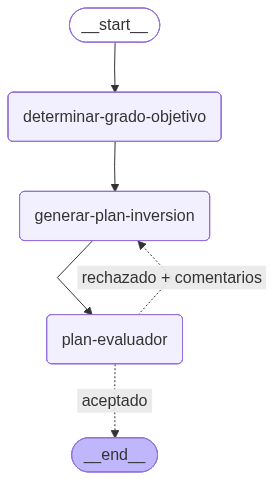

In [211]:
# display the graph
display(Image(flujo_trabajo_optimizador.get_graph().draw_mermaid_png()))

### *4.9. Prueba (Reflexión)*

Finalmente, probaremos el flujo de trabajo invocándolo con un perfil de inversión de ejemplo para ver el proceso de generación del plan de inversión de extremo a extremo en acción:

In [ ]:
# invoke the workflow with an example investor profile
respuesta = flujo_trabajo_optimizador.invoke({
    "perfil_inversionista": (
        "Edad: 29\n"
        "Salario: $110,000\n"
        "Activos: $40,000\n"
        "Objetivo: Lograr la independencia financiera para los 45 años\n"
        "Tolerancia al riesgo: Alta"
    )
})

=== ENRUTADOR  ===
Grado actual: 'alto riesgo'
Perfil de seguridad: 'agresiva'
Coincidencia: False
úmero de intentos: 1
→ Grado objetivo no alcanzado, enviando de vuelta para refinamiento
=== ENRUTADOR  ===
Grado actual: 'moderado'
Perfil de seguridad: 'agresiva'
Coincidencia: False
úmero de intentos: 2
→ Grado objetivo no alcanzado, enviando de vuelta para refinamiento
=== ENRUTADOR  ===
Grado actual: 'agresivo'
Perfil de seguridad: 'agresiva'
Coincidencia: False
úmero de intentos: 3
→ Grado objetivo no alcanzado, enviando de vuelta para refinamiento
=== ENRUTADOR  ===
Grado actual: 'moderado'
Perfil de seguridad: 'agresiva'
Coincidencia: False
úmero de intentos: 4
→ Grado objetivo no alcanzado, enviando de vuelta para refinamiento
=== ENRUTADOR  ===
Grado actual: 'moderado'
Perfil de seguridad: 'agresiva'
Coincidencia: False
úmero de intentos: 5
→ Grado objetivo no alcanzado, enviando de vuelta para refinamiento
=== ENRUTADOR  ===
Grado actual: 'moderado'
Perfil de seguridad: 'agresi

Podemos ver el estado final devuelto del flujo de trabajo a continuación:

In [ ]:
def imprimir_estado_final(estado: dict):
    print("🎯 Final Investment Plan Summary\n" + "="*40)
    print(f"\n📌 Perfil del inversor:\n{estado['perfil_inversionista']}")
    
    print("\n📈 Grado del riesgo:", estado['perfil_seguridad'])
    print("📊 Calificación final asignada:", estado['grado'])
    print("🔁 Iteraciones tomadas:", estado['n'])

    print("\n📝 Comentarios del evaluador:\n" + "-"*30)
    print(estado['comentarios'])

    print("\n📃 Plan de inversión final:\n" + "-"*30)
    print(estado['plan_inversion'])

imprimir_estado_final(respuesta)

🎯 Final Investment Plan Summary

📌 Perfil del inversor:
Edad: 29
Salario: $110,000
Activos: $40,000
Objetivo: Lograr la independencia financiera para los 45 años
Tolerancia al riesgo: Alta

📈 Grado del riesgo: agresiva
📊 Calificación final asignada: moderado
🔁 Iteraciones tomadas: 6

📝 Comentarios del evaluador:
------------------------------
La estrategia de inversión propuesta, aunque diversificada y adaptable, se asigna un grado moderado de riesgo debido a la inclusión de acciones de crecimiento y la posibilidad de apalancamiento. Si bien se prioriza la preservación del capital a través de bonos y acciones defensivas, la exposición a activos volátiles y el enfoque en un rendimiento ambicioso del 15% pueden aumentar la probabilidad de pérdidas. La claridad empresarial y los fundamentos de calidad son considerados, pero la alta asignación a acciones de crecimiento y la inclusión de apalancamiento presentan riesgos que podrían no alinearse completamente con la filosofía de inversión co

## 5. Conclusión

En este laboratorio, exploramos cómo **LangGraph** le permite crear flujos de trabajo de IA dinámicos y agentes.

A lo largo, aprendimos y aplicamos conceptos importantes como:

1. **Patrón orquestador-trabajador** 
- Planificación de alto nivel con un nodo orquestador. 
- Ejecución de tareas paralelas por nodos de trabajadores independientes. 
- Fusión automática de estados a través de campos "anotados"

2. **Patrón de reflexión** 
- Ciclos iterativos de generación y evaluación inspirados en personajes de inversores reales. 
- Comentarios estructurados utilizando analizadores de salida de Pydantic 
- Enrutamiento condicional para refinar o aceptar resultados hasta que cumplan los objetivos

3. **Gestión de estado y enrutamiento** 
- Un esquema de "Estado" compartido que transmite contexto entre nodos 
- Distribución flexible y bordes condicionales (`Enviar`, `add_conditional_edges`) 
- Control de bucle mediante contadores de iteraciones y lógica de enrutamiento

4. **Visualización y pruebas** 
- Diagramas de sirena para inspección de estructura gráfica. 
- Simulaciones manuales y utilidades de impresión bonita para depuración y presentación.

## 6. Próximos pasos



- **Consulte [Watsonx Orchestrate](https://www.ibm.com/products/watsonx-orchestrate?utm_source=skills_network&utm_content=in_lab_content_link&utm_id=Lab-Agentic+Design+Patterns+in+LangGraph-v1_1752612018)**: agentes de IA para empresas para automatizar y manejar tareas simples mediante orquestación.
- **Amplíe los patrones**: pruebe el patrón optimizador (planificar-evaluar) o combine la reflexión con el aprendizaje por refuerzo.
- **Adaptación del dominio**: cambie la lista de compras o el ejemplo de inversión por atención al cliente, redacción legal o control robótico.
- **Monitoreo y métricas**: instrumente su gráfico con registros, seguimiento de latencia y métricas de éxito/fracaso.
- **Manejo de errores y solidez**: agregue políticas de reintento, nodos alternativos y alertas para la preparación de la producción.

Al dominar estos patrones de diseño (**orquestación**, **evaluación**, **reflexión** y **enrutamiento**), puede crear verdaderos **sistemas activos** que planifican, critican, se adaptan y mejoran con el tiempo.

#### ¡Feliz edificio!

Copyright © IBM Corporation. All rights reserved (Español)
